# Lab Assignment: Data Quality & Data Cleaning for Data Warehouse

**สถานการณ์:** คุณเป็น Data Engineer ของร้านค้าออนไลน์ และได้รับไฟล์ `e_commerce_raw.csv` ที่ต้องเตรียมก่อนโหลดเข้าสู่ Data Warehouse  
**เป้าหมาย:** สำรวจปัญหาคุณภาพข้อมูล ออกแบบกฎการทำความสะอาด และส่งออกข้อมูลที่พร้อมใช้งาน

> ห้ามลบข้อมูลผิดปกติโดยไม่อธิบายเหตุผล ต้องพิจารณา Business Context โดยเฉพาะรายการโปรโมชัน


## ผลลัพธ์การเรียนรู้
1. ตรวจสอบข้อมูลด้วย `info()`, `isnull()`, `describe()` และ `duplicated()`
2. เชื่อมโยงปัญหากับ 6 มิติ: Accuracy, Completeness, Consistency, Uniqueness, Timeliness, Validity
3. จัดการ Missing Values และรูปแบบข้อมูลที่ไม่สอดคล้อง
4. ตรวจจับ Outlier ด้วย IQR และทำ Capping อย่างมีเหตุผล
5. สร้างไฟล์ Clean Data และรายงาน Data Quality ก่อน–หลัง


## 0) เตรียมระบบและอ่านข้อมูล

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == '/content/customer_reference.csv' else Path.cwd()
DATA_PATH = ROOT / 'data' / '/content/e_commerce_raw.csv'
OUTPUT_DIR = ROOT / 'outputs' / 'student_submission'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 50)
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()
print('Shape:', df.shape)
df.head()

Shape: (630, 16)


,Transaction_ID,Customer_ID,Customer_Name,Customer_Email,Gender,Province,Order_Date,Load_Timestamp,Product_Category,Quantity,Unit_Price,Discount_Rate,Transaction_Amount,Payment_Method,Order_Status,Is_Promotion
0,T000127,C0103,Tee Phromla,tee.phromla103@example.com,female,Phuket,2026-06-11,2026-06-11 05:00:00,Sports,3,110.26,0.05,314.24,PP,Cancelled,N
1,T000169,C0138,Mint Dechawat,mint.dechawat138@example.com,M,Khon Kaen,2026-01-24,2026-01-24 01:00:00,Home,3,138.08,0.05,393.53,PromptPay,Processing,N
2,T000003,C0071,Aom Sukjai,aom.sukjai71@example.com,m,Chanthaburi,05/29/2026,2026-05-29 05:00:00,Home,4,263.93,0.00,1055.72,COD,Cancelled,N
3,T000336,C0152,Tee Dechawat,tee.dechawat152@example.com,male,Chanthaburi,02/01/2026,2026-02-01 18:00:00,Food,6,116.53,0.10,629.26,Transfer,Returned,N
4,T000093,C0090,Mook Sukjai,mook.sukjai90@example.com,M,Chanthaburi,2026-04-18,2026-04-18 13:00:00,Electronics,5,358.35,0.00,1791.75,promptpay,Processing,N


## 1) Data Profiling

ให้แสดงผลต่อไปนี้และเขียนข้อสังเกตใต้เซลล์
- โครงสร้างและชนิดข้อมูล
- จำนวน Missing Values รายคอลัมน์
- สถิติเชิงพรรณนาของข้อมูลตัวเลข
- จำนวนแถวซ้ำทั้งแถว
- จำนวนค่าที่แตกต่างในคอลัมน์สำคัญ


In [5]:
# TODO 1: Data Profiling
# ตัวอย่างคำสั่งที่ควรใช้: df.info(), df.isnull().sum(), df.describe(), df.duplicated().sum()
df.info()
df.isnull().sum()
df.describe()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630 entries, 0 to 629
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction_ID      630 non-null    object 
 1   Customer_ID         630 non-null    object 
 2   Customer_Name       630 non-null    object 
 3   Customer_Email      580 non-null    object 
 4   Gender              630 non-null    object 
 5   Province            618 non-null    object 
 6   Order_Date          630 non-null    object 
 7   Load_Timestamp      630 non-null    object 
 8   Product_Category    630 non-null    object 
 9   Quantity            630 non-null    int64  
 10  Unit_Price          630 non-null    float64
 11  Discount_Rate       630 non-null    float64
 12  Transaction_Amount  630 non-null    float64
 13  Payment_Method      630 non-null    object 
 14  Order_Status        630 non-null    object 
 15  Is_Promotion        630 non-null    object 
dtypes: float

np.int64(18)

### คำถาม 1
ระบุปัญหาที่พบอย่างน้อย **5 ปัญหา** และจับคู่กับมิติ Data Quality อย่างน้อย **3 มิติ**

| ปัญหาที่พบ | คอลัมน์ | มิติ Data Quality | หลักฐาน/จำนวนแถว |
|---|---|---|---|
| | | | |


In [6]:
"""
| ข้อมูลสูญหาย (Missing Values)            | `Customer_Email` | **Completeness**  | มีข้อมูล 580 จาก 630 แถว → ขาด **50 แถว**                          |
| ข้อมูลสูญหาย (Missing Values)            | `Province`       | **Completeness**  | มีข้อมูล 618 จาก 630 แถว → ขาด **12 แถว**                          |
| ชนิดข้อมูลไม่เหมาะสม                     | `Order_Date`     | **Validity**      | เก็บเป็น `object` ควรเป็น `datetime`                               |
| ชนิดข้อมูลไม่เหมาะสม                     | `Load_Timestamp` | **Validity**      | เก็บเป็น `object` ควรเป็น `datetime`                               |
| ความซ้ำซ้อนของข้อมูล (Duplicate Records) | ทั้งตาราง        | **Uniqueness**    | ตรวจสอบด้วย `df.duplicated().sum()` (ใช้จำนวนที่ได้จากผลลัพธ์จริง) |
"""

'\n| ข้อมูลสูญหาย (Missing Values)            | `Customer_Email` | **Completeness**  | มีข้อมูล 580 จาก 630 แถว → ขาด **50 แถว**                          |\n| ข้อมูลสูญหาย (Missing Values)            | `Province`       | **Completeness**  | มีข้อมูล 618 จาก 630 แถว → ขาด **12 แถว**                          |\n| ชนิดข้อมูลไม่เหมาะสม                     | `Order_Date`     | **Validity**      | เก็บเป็น `object` ควรเป็น `datetime`                               |\n| ชนิดข้อมูลไม่เหมาะสม                     | `Load_Timestamp` | **Validity**      | เก็บเป็น `object` ควรเป็น `datetime`                               |\n| ความซ้ำซ้อนของข้อมูล (Duplicate Records) | ทั้งตาราง        | **Uniqueness**    | ตรวจสอบด้วย `df.duplicated().sum()` (ใช้จำนวนที่ได้จากผลลัพธ์จริง) |\n'

## 2) Completeness: จัดการ Missing Values

In [7]:
# TODO 2.1: ตรวจสอบ Customer_Email และ Province ที่หายไป

missing_email = df['Customer_Email'].isna().sum()
missing_province = df['Province'].isna().sum()

print("Missing Customer_Email :", missing_email)
print("Missing Province       :", missing_province)

Missing Customer_Email : 50
Missing Province       : 12


In [8]:
# TODO 2.2: ออกแบบวิธีเติม Customer_Email โดยต้องไม่ทำให้แถว Fact หาย
# แนวคิดสำหรับ DW: unknown member / surrogate placeholder และสร้าง flag เพื่อย้อนตรวจสอบได้
df['Email_Missing_Flag'] = df['Customer_Email'].isna()

df['Customer_Email'] = df['Customer_Email'].fillna('unknown_' + df['Customer_ID'].astype(str) + '@unknown.local')

In [9]:
# TODO 2.3: เติม Province ที่หายเป็น 'Unknown' พร้อม flag
df['Province_Missing_Flag'] = df['Province'].isna()

df['Province'] = df['Province'].fillna('Unknown')

In [10]:
print("\nAfter Cleaning")
print(df[['Customer_Email',
          'Email_Missing_Flag',
          'Province',
          'Province_Missing_Flag']].head())

print("\nRemaining Missing Values")
print(df[['Customer_Email','Province']].isna().sum())


After Cleaning
                 Customer_Email  Email_Missing_Flag     Province  \
0    tee.phromla103@example.com               False       Phuket   
1  mint.dechawat138@example.com               False    Khon Kaen   
2      aom.sukjai71@example.com               False  Chanthaburi   
3   tee.dechawat152@example.com               False  Chanthaburi   
4     mook.sukjai90@example.com               False  Chanthaburi   

   Province_Missing_Flag  
0                  False  
1                  False  
2                  False  
3                  False  
4                  False  

Remaining Missing Values
Customer_Email    0
Province          0
dtype: int64


เหตุผลที่ใช้ Mean Imputation กับอีเมลไม่ได้

=ผิดประเภทข้อมูล: อีเมลเป็น ข้อความ (Text) ไม่ใช่ตัวเลข จึงนำมาบวกหารหาค่าเฉลี่ยทางคณิตศาสตร์ไม่ได้ (จะเกิด System Error ทันที)

=เสียตัวระบุตัวตน: อีเมลใช้ระบุตัวตนเฉพาะบุคคล (Unique Identifier) การเติมค่ากลางๆ จะทำให้ข้อมูลลูกค้าซ้ำซ้อนและปะปนกัน

=ผิดหลัก Data Integrity: ค่าเฉลี่ยไม่มีอยู่จริงในรูปแบบรูปแบบโครงสร้างของอีเมล (เช่น name@domain.com)

### คำถาม 2
อธิบายว่าเหตุใดการใช้ `dropna()` กับ `Customer_Email` อาจทำให้ยอดขายรวมใน Data Warehouse ผิดเพี้ยน และเหตุใดการเติมค่าเฉลี่ยจึงไม่เหมาะกับข้อมูลประเภทอีเมล


=ทำไม dropna() ทำให้อยอดขายผิดเพี้ยน:
เพราะการลบแถวที่ไม่มีอีเมลทิ้ง จะทำให้รายการซื้อขายจริง (เช่น ลูกค้าที่ซื้อแบบ ไม่กรอกอีเมล/Guest) ถูกลบหายไปด้วย ยอดขายรวมทางการเงินจึงต่ำกว่าความเป็นจริง

=ทำไมเติมค่าเฉลี่ย (Mean) ไม่ได้:
เพราะอีเมลเป็น ข้อความ (Text) ไม่ใช่ตัวเลข จึงนำมาคำนวณบวกหารหาค่าเฉลี่ยทางคณิตศาสตร์ไม่ได้

## 3) Consistency: จัดรูปแบบข้อมูลให้เป็นมาตรฐาน

In [11]:
# TODO 3.1: Standardize Gender ให้เหลือ M, F, Unknown
gender_map = {
    'm': 'M', 'male': 'M',
    'f': 'F', 'female': 'F'
}
df['Gender'] = (
    df['Gender']
    .astype(str)
    .str.strip()
    .str.lower()
    .map(gender_map)
    .fillna('Unknown')
)

In [12]:
# TODO 3.2: Standardize Payment_Method ให้เหลือ
# Credit Card, PromptPay, Cash on Delivery, Bank Transfer, Unknown
def standardize_payment(val):
    if pd.isna(val):
        return 'Unknown'

    val_str = str(val).strip().lower()

    # ตรวจจับทั้งชื่อเต็มและตัวย่อ (CC, PP, COD)
    if 'credit' in val_str or 'card' in val_str or val_str == 'cc':
        return 'Credit Card'
    elif 'prompt' in val_str or val_str == 'pp':
        return 'PromptPay'
    elif 'cash' in val_str or val_str == 'cod':
        return 'Cash on Delivery'
    elif 'bank' in val_str or 'transfer' in val_str:
        return 'Bank Transfer'
    else:
        return 'Unknown'

df['Payment_Method'] = df['Payment_Method'].apply(standardize_payment)

In [13]:
# TODO 3.3: แปลง Order_Date ซึ่งมีหลายรูปแบบให้เป็น YYYY-MM-DD
# ระวังความกำกวมระหว่าง DD/MM/YYYY และ MM/DD/YYYY
# ใช้ Load_Timestamp เป็นข้อมูลประกอบ และสร้าง flag สำหรับค่าที่ต้อง fallback/impute
load_dt = pd.to_datetime(df['Load_Timestamp'], errors='coerce')
order_dates_parsed = []
parse_methods = []
was_imputed = []

for raw_date, ref_dt in zip(df['Order_Date'], load_dt):
    # กรณีข้อมูลว่างเปล่า (NaN / None)
    if pd.isna(raw_date):
        order_dates_parsed.append(ref_dt.strftime('%Y-%m-%d') if pd.notna(ref_dt) else None)
        parse_methods.append('Fallback_Load_Timestamp')
        was_imputed.append(True)
        continue

    # 1. ลองพาร์สแบบ ISO Format (YYYY-MM-DD / YYYY/MM/DD) ก่อน
    dt_iso = pd.to_datetime(raw_date, format='%Y-%m-%d', errors='coerce')
    if pd.isna(dt_iso):
        dt_iso = pd.to_datetime(raw_date, format='%Y/%m/%d', errors='coerce')

    if pd.notna(dt_iso):
        order_dates_parsed.append(dt_iso.strftime('%Y-%m-%d'))
        parse_methods.append('Standard_ISO')
        was_imputed.append(False)
        continue

    # 2. กรณีรูปแบบวันที่กำกวม (เช่น 02/06/2026 -> 2 มิ.ย. หรือ 6 ก.พ.)
    dt_dayfirst = pd.to_datetime(raw_date, format='%d/%m/%Y', errors='coerce')
    if pd.isna(dt_dayfirst):
        dt_dayfirst = pd.to_datetime(raw_date, format='%d-%m-%Y', errors='coerce')

    dt_monthfirst = pd.to_datetime(raw_date, format='%m/%d/%Y', errors='coerce')
    if pd.isna(dt_monthfirst):
        dt_monthfirst = pd.to_datetime(raw_date, format='%m-%d-%Y', errors='coerce')

    # พิจารณาผลลัพธ์
    if pd.notna(dt_dayfirst) and pd.isna(dt_monthfirst):
        order_dates_parsed.append(dt_dayfirst.strftime('%Y-%m-%d'))
        parse_methods.append('Parsed_DayFirst')
        was_imputed.append(False)
    elif pd.isna(dt_dayfirst) and pd.notna(dt_monthfirst):
        order_dates_parsed.append(dt_monthfirst.strftime('%Y-%m-%d'))
        parse_methods.append('Parsed_MonthFirst')
        was_imputed.append(False)
    elif pd.notna(dt_dayfirst) and pd.notna(dt_monthfirst):
        # ทั้งคู่พาร์สได้ (กำกวม) -> ตัดสินด้วย Load_Timestamp
        if pd.notna(ref_dt):
            valid_df = dt_dayfirst <= ref_dt
            valid_mf = dt_monthfirst <= ref_dt

            if valid_df and not valid_mf:
                chosen = dt_dayfirst
                method = 'Resolved_DayFirst'
            elif valid_mf and not valid_df:
                chosen = dt_monthfirst
                method = 'Resolved_MonthFirst'
            else:
                # ถ้าเข้าเงื่อนไขทั้งคู่ เลือกอันที่ใกล้เคียง Load_Timestamp มากที่สุด
                diff_df = abs((ref_dt - dt_dayfirst).total_seconds())
                diff_mf = abs((ref_dt - dt_monthfirst).total_seconds())
                if diff_df <= diff_mf:
                    chosen = dt_dayfirst
                    method = 'Resolved_DayFirst'
                else:
                    chosen = dt_monthfirst
                    method = 'Resolved_MonthFirst'
        else:
            chosen = dt_dayfirst
            method = 'Resolved_Default_DayFirst'

        order_dates_parsed.append(chosen.strftime('%Y-%m-%d'))
        parse_methods.append(method)
        was_imputed.append(False)
    else:
        # พาร์สไม่ได้เลย -> Fallback ไปใช้ Load_Timestamp
        order_dates_parsed.append(ref_dt.strftime('%Y-%m-%d') if pd.notna(ref_dt) else None)
        parse_methods.append('Fallback_Load_Timestamp')
        was_imputed.append(True)

# บันทึกคอลัมน์กลับเข้า DataFrame
df['Order_Date'] = order_dates_parsed
df['Order_Date_Parse_Method'] = parse_methods
df['Order_Date_Was_Imputed'] = was_imputed

### คำถาม 3
ยกตัวอย่าง 1 วันที่สามารถตีความได้ทั้ง DD/MM/YYYY และ MM/DD/YYYY แล้วอธิบายว่าคุณใช้หลักฐานใดช่วยตัดสิน


จะใช้ (Load_Timestamp) เพื่อเป็นหลักฐานในการตัดสิน
เนื่องจากในระบบ Data Warehouse

วันที่สั่งซื้อ (Order_Date) จะต้องเกิดขึ้นก่อนหรือในวันเดียวกับวันที่บันทึกข้อมูล

## 4) Uniqueness: ข้อมูลซ้ำและความซ้ำซ้อนเชิงความหมาย

In [14]:
# TODO 4.1: นับและลบ Exact Duplicates โดยเก็บแถวแรก
exact_dup_count = df.duplicated().sum()
print(f"จำนวน Exact Duplicates ทั้งหมด: {exact_dup_count} แถว")

# 2. ลบ Exact Duplicates โดยเก็บแถวแรกไว้
df = df.drop_duplicates(keep='first').copy()
print(f"Shape หลังลบ Exact Duplicates: {df.shape}")

จำนวน Exact Duplicates ทั้งหมด: 18 แถว
Shape หลังลบ Exact Duplicates: (612, 20)


In [15]:
# TODO 4.2 (Bonus): ตรวจหาลูกค้าที่ Customer_Email เดียวกัน แต่ Customer_Name เขียนต่างกัน
# อธิบายว่าเหตุใด drop_duplicates() เพียงอย่างเดียวจึงตรวจไม่พบ Near Duplicate
valid_email_df = df[
    df['Customer_Email'].notna() &
    ~df['Customer_Email'].astype(str).str.contains('unknown', case=False)
]

# หา Customer_Email ที่ผูกกับ Customer_Name มากกว่า 1 ชื่อ
email_name_counts = valid_email_df.groupby('Customer_Email')['Customer_Name'].nunique()
near_dup_emails = email_name_counts[email_name_counts > 1].index

# แสดงรายการ Near Duplicates ที่ตรวจพบ
near_duplicates = valid_email_df[valid_email_df['Customer_Email'].isin(near_dup_emails)][
    ['Customer_ID', 'Customer_Email', 'Customer_Name']
].drop_duplicates()

print("\n--- รายการ Near Duplicates ที่ตรวจพบ (Same Email, Different Names) ---")
print(near_duplicates)

'''
เพราะสั่งลบได้เฉพาะข้อมูลที่ตรงกันเป๊ะ $100\%$ ทุกตัวอักษรเท่านั้น
หากต่างกันแค่การเว้นวรรค (เช่น 'Ploy Saelim' กับ 'Ploy  Saelim')
ระบบจะมองว่าเป็นคนละคนทันที
'''


--- รายการ Near Duplicates ที่ตรวจพบ (Same Email, Different Names) ---
   Customer_ID             Customer_Email Customer_Name
96       C0047  ploy.saelim47@example.com   Ploy Saelim
97       C0047  ploy.saelim47@example.com  Ploy  Saelim


<>:21: SyntaxWarning: invalid escape sequence '\%'
<>:21: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_1928/3285571505.py:21: SyntaxWarning: invalid escape sequence '\%'
  เพราะสั่งลบได้เฉพาะข้อมูลที่ตรงกันเป๊ะ $100\%$ ทุกตัวอักษรเท่านั้น


"\nเพราะสั่งลบได้เฉพาะข้อมูลที่ตรงกันเป๊ะ $100\\%$ ทุกตัวอักษรเท่านั้น\nหากต่างกันแค่การเว้นวรรค (เช่น 'Ploy Saelim' กับ 'Ploy  Saelim')\nระบบจะมองว่าเป็นคนละคนทันที\n"

## 5) Accuracy และ Validity: ตรวจสอบกฎธุรกิจ

In [16]:
# TODO 5.1: แปลง Quantity, Unit_Price, Discount_Rate และ Transaction_Amount เป็นตัวเลข
num_cols = ['Quantity', 'Unit_Price', 'Discount_Rate', 'Transaction_Amount']

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# TODO 5.2: ตรวจ Quantity ต้องอยู่ในช่วง 1-20
df['Quantity_Was_Invalid'] = ~df['Quantity'].between(1, 20)

# TODO 5.3: คำนวณ Expected_Amount = Quantity * Unit_Price * (1 - Discount_Rate)
# สร้าง Accuracy_Flag เมื่อผลต่างเกิน 1 บาท
# คำนวณ Expected_Amount
df['Expected_Amount'] = df['Quantity'] * df['Unit_Price'] * (1 - df['Discount_Rate'])

# คำนวณผลต่าง absolute difference ระหว่าง Transaction_Amount กับ Expected_Amount
abs_diff = (df['Transaction_Amount'] - df['Expected_Amount']).abs()

# สร้าง Accuracy_Flag: ติด True เมื่อผลต่างมากกว่า 1 บาท
df['Accuracy_Flag'] = abs_diff > 1.0

# TODO 5.4: Standardize Order_Status และตรวจ Validity
# Map ตัวสะกดต่าง ๆ ให้อยู่ในรูปแบบ Completed, Processing, Cancelled, Returned
status_map = {
    'completed': 'Completed', 'done': 'Completed',
    'processing': 'Processing',
    'cancelled': 'Cancelled', 'cancel': 'Cancelled',
    'returned': 'Returned'
}

# ทำความสะอาดสตริงเบื้องต้นก่อน Map
clean_status = df['Order_Status'].astype(str).str.strip().str.lower()
df['Order_Status'] = clean_status.map(status_map).fillna('Unknown')

# ตรวจสอบค่าที่ไม่ใช่อยู่ในกลุ่ม Completed, Processing, Cancelled, Returned
valid_statuses = ['Completed', 'Processing', 'Cancelled', 'Returned']
df['Order_Status_Was_Invalid'] = ~df['Order_Status'].isin(valid_statuses)

### คำถาม 4
รายการที่ `Transaction_Amount` ไม่ตรงกับสูตรควรแก้ไขทุกแถวหรือไม่? ให้อธิบายผลของ `Is_Promotion` ต่อการตัดสินใจ


ควรแก้ทุกแถวหรือไม่: ไม่ควร เพราะยอดที่ไม่ตรงอาจเกิดจากส่วนลดพิเศษอื่นๆ (เช่น คูปอง, แต้มสะสม) ที่ไม่ได้อยู่ในสูตรคำนวณ หากแก้ทันทีจะทำให้ยอดขายจริงผิดเพี้ยน

ผลของ Is_Promotion ต่อการตัดสินใจ:

Is_Promotion = Y: ยอดไม่ตรงมักเกิดจากแคมเปญการตลาด/คูปองพิเศษ $\rightarrow$ ห้ามแก้ทันที ให้เช็กเงื่อนไขโปรโมชันก่อน

Is_Promotion = N: ยอดไม่ตรงมักเกิดจากระบบบันทึกผิดพลาด (Data Entry / System Bug) $\rightarrow$ สามารถปรับแก้ตาม Expected_Amount หรือส่งตรวจสอบได้ง่ายกว่า

## 6) Outliers: IQR และ Capping/Clipping

In [17]:
# TODO 6.1: ใช้เฉพาะรายการที่ Is_Promotion != 'Y' คำนวณ Q1, Q3, IQR, Lower Bound, Upper Bound
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. ใช้เฉพาะรายการที่ Is_Promotion != 'Y' คำนวณ Q1, Q3, IQR, Lower Bound, Upper Bound
df_non_promo = df[df['Is_Promotion'] != 'Y']['Transaction_Amount']

Q1 = df_non_promo.quantile(0.25)
Q3 = df_non_promo.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (Non-Promotion): {Q1:.2f}")
print(f"Q3 (Non-Promotion): {Q3:.2f}")
print(f"IQR (Non-Promotion): {IQR:.2f}")
print(f"Lower Bound (Non-Promotion): {lower_bound:.2f}")
print(f"Upper Bound (Non-Promotion): {upper_bound:.2f}")

Q1 (Non-Promotion): 310.80
Q3 (Non-Promotion): 1023.48
IQR (Non-Promotion): 712.68
Lower Bound (Non-Promotion): -758.22
Upper Bound (Non-Promotion): 2092.50


In [19]:
# TODO 6.2: สร้าง Outlier Flag ก่อนทำ Capping
# 2. สร้าง Outlier Flag ก่อนทำ Capping
df['Transaction_Amount_Outlier_Flag'] = False
df.loc[(df['Is_Promotion'] != 'Y') &
       ((df['Transaction_Amount'] < lower_bound) | (df['Transaction_Amount'] > upper_bound)),
       'Transaction_Amount_Outlier_Flag'] = True

outlier_count = df['Transaction_Amount_Outlier_Flag'].sum()
print(f"จำนวน Outliers (Non-Promotion) ก่อน Capping: {outlier_count} แถว")

จำนวน Outliers (Non-Promotion) ก่อน Capping: 19 แถว


In [20]:
# TODO 6.3: ใช้ .clip() กับ Transaction_Amount เฉพาะรายการที่ไม่ใช่โปรโมชัน

# 3. ใช้ .clip() กับ Transaction_Amount เฉพาะรายการที่ไม่ใช่โปรโมชัน
# ทำสำเนาของคอลัมน์ Transaction_Amount เพื่อเก็บค่าก่อนและหลัง Capping
df['Transaction_Amount_Capped'] = df['Transaction_Amount']

# ใช้ .clip() เฉพาะแถวที่ Is_Promotion != 'Y'
df.loc[df['Is_Promotion'] != 'Y', 'Transaction_Amount_Capped'] = \
    df.loc[df['Is_Promotion'] != 'Y', 'Transaction_Amount'].clip(lower=lower_bound, upper=upper_bound)

print("ตัวอย่างข้อมูล Transaction_Amount ก่อนและหลัง Capping:")
display(df[['Transaction_ID', 'Is_Promotion', 'Transaction_Amount', 'Transaction_Amount_Outlier_Flag', 'Transaction_Amount_Capped']].head())

ตัวอย่างข้อมูล Transaction_Amount ก่อนและหลัง Capping:


,Transaction_ID,Is_Promotion,Transaction_Amount,Transaction_Amount_Outlier_Flag,Transaction_Amount_Capped
0,T000127,N,314.24,False,314.24
1,T000169,N,393.53,False,393.53
2,T000003,N,1055.72,False,1055.72
3,T000336,N,629.26,False,629.26
4,T000093,N,1791.75,False,1791.75


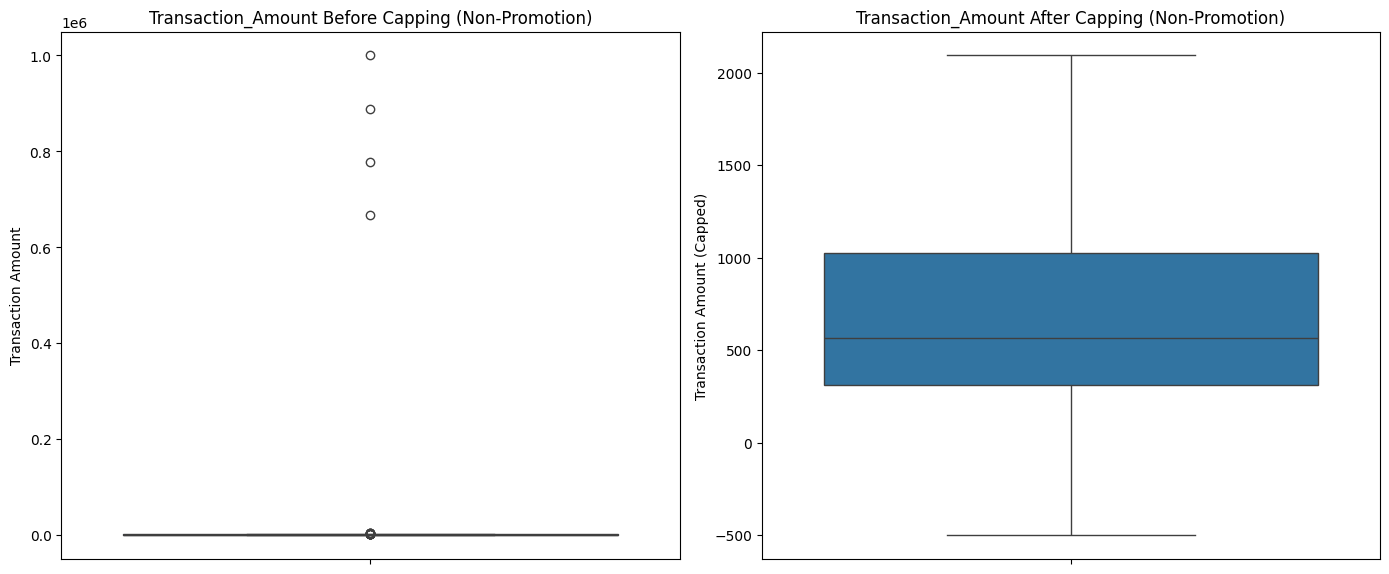

In [21]:
# TODO 6.4: วาด Boxplot ก่อนและหลัง Capping

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=df.loc[df['Is_Promotion'] != 'Y', 'Transaction_Amount'])
plt.title('Transaction_Amount Before Capping (Non-Promotion)')
plt.ylabel('Transaction Amount')

plt.subplot(1, 2, 2)
sns.boxplot(y=df.loc[df['Is_Promotion'] != 'Y', 'Transaction_Amount_Capped'])
plt.title('Transaction_Amount After Capping (Non-Promotion)')
plt.ylabel('Transaction Amount (Capped)')

plt.tight_layout()
plt.show()

### คำถาม 5
เพราะเหตุใดข้อมูลที่อยู่นอก IQR Bound จึงไม่จำเป็นต้องเป็นข้อมูลผิดเสมอ? ยกตัวอย่างจาก Dataset นี้


IQR เป็นแค่เกณฑ์ทางสถิติที่บอกว่า "แปลกแยกจากคนส่วนใหญ่" ไม่ใช่ "บันทึกผิด"

ข้อมูลส่วนใหญ่เป็น ยอดซื้อขายจริงของลูกค้ารายใหญ่ (VIP) หากลบทิ้งจะทำให้ยอดขายรวมของบริษัทต่ำกว่าความเป็นจริง

## 7) Timeliness: ความทันเวลาในการโหลดข้อมูล

In [22]:
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'src' else Path.cwd()
OUTPUT_DIR = ROOT / 'outputs' / 'student_submission'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [23]:
# TODO 7: คำนวณ Load_Delay_Hours จาก Order_Date ถึง Load_Timestamp
# กำหนด Late เมื่อมากกว่า 24 ชั่วโมง และสรุปจำนวน/ร้อยละ
# Convert Order_Date and Load_Timestamp to datetime objects
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Load_Timestamp'] = pd.to_datetime(df['Load_Timestamp'])

# Calculate Load_Delay in hours
df['Load_Delay'] = df['Load_Timestamp'] - df['Order_Date']
df['Load_Delay_Hours'] = df['Load_Delay'].dt.total_seconds() / 3600

# Define 'Late' when Load_Delay_Hours is greater than 24
df['Is_Late_Load'] = df['Load_Delay_Hours'] > 24

# Summarize the count and percentage of late loads
late_load_count = df['Is_Late_Load'].sum()
total_orders = len(df)
late_load_percentage = (late_load_count / total_orders) * 100

print(f"จำนวนรายการโหลดล่าช้า (> 24 ชั่วโมง): {late_load_count} รายการ")
print(f"คิดเป็นร้อยละ: {late_load_percentage:.2f}%")

display(df[['Order_Date', 'Load_Timestamp', 'Load_Delay_Hours', 'Is_Late_Load']].head())

จำนวนรายการโหลดล่าช้า (> 24 ชั่วโมง): 38 รายการ
คิดเป็นร้อยละ: 6.21%


,Order_Date,Load_Timestamp,Load_Delay_Hours,Is_Late_Load
0,2026-06-11,2026-06-11 05:00:00,5.0,False
1,2026-01-24,2026-01-24 01:00:00,1.0,False
2,2026-05-29,2026-05-29 05:00:00,5.0,False
3,2026-02-01,2026-02-01 18:00:00,18.0,False
4,2026-04-18,2026-04-18 13:00:00,13.0,False


## 8) Data Quality Report และ Export

In [24]:
# อย่างน้อย: rows, missing email, exact duplicates, invalid dates, mismatched amounts,
# outliers capped, late loads และ invalid statuses

# Define metrics labels
metrics = [
    'Total Rows',
    'Missing Customer_Email',
    'Missing Province',
    'Exact Duplicates',
    'Order_Date Needing Special Parsing/Imputation',
    'Mismatched Transaction_Amount (>1 Baht)',
    'Transaction_Amount Outliers (Non-Promo)',
    'Late Loads (>24 Hours Delay)',
    'Invalid Order_Status'
]

# --- Metrics Before Cleaning (using df_raw) ---
before_cleaning = {}
before_cleaning['Total Rows'] = df_raw.shape[0]
before_cleaning['Missing Customer_Email'] = df_raw['Customer_Email'].isna().sum()
before_cleaning['Missing Province'] = df_raw['Province'].isna().sum()
before_cleaning['Exact Duplicates'] = df_raw.duplicated().sum()

# For Order_Date needing special parsing/imputation, we use the flag from df
before_cleaning['Order_Date Needing Special Parsing/Imputation'] = df['Order_Date_Was_Imputed'].sum()

# Mismatched Transaction_Amount before cleaning - re-calculate using df_raw
df_raw_expected_amount = df_raw['Quantity'] * df_raw['Unit_Price'] * (1 - df_raw['Discount_Rate'])
df_raw_abs_diff = (df_raw['Transaction_Amount'] - df_raw_expected_amount).abs()
before_cleaning['Mismatched Transaction_Amount (>1 Baht)'] = (df_raw_abs_diff > 1.0).sum()

before_cleaning['Transaction_Amount Outliers (Non-Promo)'] = 0 # No capping before cleaning
before_cleaning['Late Loads (>24 Hours Delay)'] = 0 # Not calculated before cleaning

# Invalid Order_Status before cleaning - apply standardization logic to df_raw
clean_status_raw = df_raw['Order_Status'].astype(str).str.strip().str.lower()
# Assuming valid_statuses is already defined from previous cell
before_cleaning['Invalid Order_Status'] = clean_status_raw.map(status_map).fillna('Unknown').apply(lambda x: x == 'Unknown').sum()

# --- Metrics After Cleaning (using df) ---
after_cleaning = {}
after_cleaning['Total Rows'] = df.shape[0]
after_cleaning['Missing Customer_Email'] = df['Email_Missing_Flag'].sum()
after_cleaning['Missing Province'] = df['Province_Missing_Flag'].sum()
after_cleaning['Exact Duplicates'] = df.duplicated().sum() # Should be 0 after drop_duplicates
after_cleaning['Order_Date Needing Special Parsing/Imputation'] = df['Order_Date_Was_Imputed'].sum()
after_cleaning['Mismatched Transaction_Amount (>1 Baht)'] = df['Accuracy_Flag'].sum()
after_cleaning['Transaction_Amount Outliers (Non-Promo)'] = df['Transaction_Amount_Outlier_Flag'].sum()
after_cleaning['Late Loads (>24 Hours Delay)'] = df['Is_Late_Load'].sum()
after_cleaning['Invalid Order_Status'] = df['Order_Status_Was_Invalid'].sum() # Should be 0 after standardization

# Create DataFrame for the report
report_df = pd.DataFrame({
    'Metric': metrics,
    'Before Cleaning': [before_cleaning[m] for m in metrics],
    'After Cleaning': [after_cleaning[m] for m in metrics]
})

display(report_df)

# TODO 8.2: Export
df.to_csv(OUTPUT_DIR / 'e_commerce_clean.csv', index=False, encoding='utf-8-sig')
report_df.to_csv(OUTPUT_DIR / 'data_quality_report.csv', index=False, encoding='utf-8-sig')

print(f"Cleaned data exported to: {OUTPUT_DIR / 'e_commerce_clean.csv'}")
print(f"Data Quality Report exported to: {OUTPUT_DIR / 'data_quality_report.csv'}")

,Metric,Before Cleaning,After Cleaning
0,Total Rows,630,612
1,Missing Customer_Email,50,48
2,Missing Province,12,12
3,Exact Duplicates,18,0
4,Order_Date Needing Special Parsing/Imputation,7,7
5,Mismatched Transaction_Amount (>1 Baht),51,50
6,Transaction_Amount Outliers (Non-Promo),0,19
7,Late Loads (>24 Hours Delay),0,38
8,Invalid Order_Status,5,5


Cleaned data exported to: /content/outputs/student_submission/e_commerce_clean.csv
Data Quality Report exported to: /content/outputs/student_submission/data_quality_report.csv


In [25]:
cleaned_df = pd.read_csv(OUTPUT_DIR / 'e_commerce_clean.csv')
display(cleaned_df.head())

,Transaction_ID,Customer_ID,Customer_Name,Customer_Email,Gender,Province,Order_Date,Load_Timestamp,Product_Category,Quantity,Unit_Price,Discount_Rate,Transaction_Amount,Payment_Method,Order_Status,Is_Promotion,Email_Missing_Flag,Province_Missing_Flag,Order_Date_Parse_Method,Order_Date_Was_Imputed,Quantity_Was_Invalid,Expected_Amount,Accuracy_Flag,Order_Status_Was_Invalid,Transaction_Amount_Capped,Transaction_Amount_Outlier_Flag,Load_Delay,Load_Delay_Hours,Is_Late_Load
0,T000127,C0103,Tee Phromla,tee.phromla103@example.com,F,Phuket,2026-06-11,2026-06-11 05:00:00,Sports,3,110.26,0.05,314.24,PromptPay,Cancelled,N,False,False,Standard_ISO,False,False,314.241,False,False,314.24,False,0 days 05:00:00,5.0,False
1,T000169,C0138,Mint Dechawat,mint.dechawat138@example.com,M,Khon Kaen,2026-01-24,2026-01-24 01:00:00,Home,3,138.08,0.05,393.53,PromptPay,Processing,N,False,False,Standard_ISO,False,False,393.528,False,False,393.53,False,0 days 01:00:00,1.0,False
2,T000003,C0071,Aom Sukjai,aom.sukjai71@example.com,M,Chanthaburi,2026-05-29,2026-05-29 05:00:00,Home,4,263.93,0.00,1055.72,Cash on Delivery,Cancelled,N,False,False,Parsed_MonthFirst,False,False,1055.720,False,False,1055.72,False,0 days 05:00:00,5.0,False
3,T000336,C0152,Tee Dechawat,tee.dechawat152@example.com,M,Chanthaburi,2026-02-01,2026-02-01 18:00:00,Food,6,116.53,0.10,629.26,Bank Transfer,Returned,N,False,False,Resolved_MonthFirst,False,False,629.262,False,False,629.26,False,0 days 18:00:00,18.0,False
4,T000093,C0090,Mook Sukjai,mook.sukjai90@example.com,M,Chanthaburi,2026-04-18,2026-04-18 13:00:00,Electronics,5,358.35,0.00,1791.75,PromptPay,Processing,N,False,False,Standard_ISO,False,False,1791.750,False,False,1791.75,False,0 days 13:00:00,13.0,False


## 9) Reflection
ตอบเป็นย่อหน้าสั้น ๆ
1. ขั้นตอนใดมีความเสี่ยงทำให้ข้อมูลจริงสูญหายมากที่สุด?
2. กฎใดควรนำไปทำ Automation ใน Data Pipeline?
3. หากใช้ Great Expectations คุณจะสร้าง Expectation ใดอย่างน้อย 3 ข้อ?


In [ ]:
1. **ขั้นตอนใดมีความเสี่ยงทำให้ข้อมูลจริงสูญหายมากที่สุด?**
   ขั้นตอนที่เสี่ยงทำให้ข้อมูลจริงสูญหายมากที่สุดคือ **การลบแถวข้อมูลซ้ำทั้งหมด (Exact Duplicates) โดยไม่มีการพิจารณาบริบทที่ละเอียดอ่อน** แม้ว่าการลบข้อมูลซ้ำที่ตรงกันทุกประการจะเป็นเรื่องปกติเพื่อรักษา Uniqueness แต่หากมีกรณีที่ข้อมูลซ้ำอาจหมายถึงเหตุการณ์ที่เกิดขึ้นซ้ำจริง (เช่น รายการสั่งซื้อสองครั้งโดยลูกค้าเดียวกันในเวลาเดียวกัน แต่มี Transaction ID ต่างกัน) การลบโดยไม่ตรวจสอบ Transaction ID จะทำให้ข้อมูลนั้นสูญหายไป นอกจากนี้ **การใช้ `dropna()` โดยไม่ระมัดระวัง** ก็เป็นความเสี่ยงสูง เพราะอาจลบทั้งแถวของข้อมูลการซื้อขายออกไป ซึ่งส่งผลต่อยอดขายรวมที่ผิดเพี้ยนได้ตามที่อธิบายไปก่อนหน้านี้

2. **กฎใดควรนำไปทำ Automation ใน Data Pipeline?**
   กฎที่ควรนำไปทำ Automation ใน Data Pipeline ได้แก่:
   *   **การแปลงชนิดข้อมูล:** เช่น `Order_Date`, `Load_Timestamp` ให้เป็น datetime และคอลัมน์ตัวเลขให้เป็นชนิดข้อมูลที่ถูกต้อง
   *   **การจัดการ Missing Values:** เช่น การเติม 'Unknown' หรือค่า fallback ที่มี `Flag` สำหรับ `Customer_Email` และ `Province`
   *   **การ Standardize ข้อมูล:** เช่น `Gender` (M, F, Unknown), `Payment_Method` (Credit Card, PromptPay, Cash on Delivery, Bank Transfer, Unknown), `Order_Status` (Completed, Processing, Cancelled, Returned, Unknown)
   *   **การลบ Exact Duplicates:** เพื่อรักษา Uniqueness ของ Transaction
   *   **การสร้าง Flag สำหรับข้อมูลที่ผิดปกติ:** เช่น `Accuracy_Flag` สำหรับยอดเงินที่ไม่ตรงสูตร, `Load_Delay_Hours` และ `Is_Late_Load` เพื่อระบุการโหลดล่าช้า, `Quantity_Was_Invalid`, `Order_Status_Was_Invalid`
   *   **การทำ Capping Outliers:** สำหรับคอลัมน์ตัวเลข เช่น `Transaction_Amount` โดยแยกพิจารณารายการโปรโมชัน

3. **หากใช้ Great Expectations คุณจะสร้าง Expectation ใดอย่างน้อย 3 ข้อ?**
   หากใช้ Great Expectations, สามารถสร้าง Expectation ได้ดังนี้:
   *   `expect_column_values_to_not_be_null`: สำหรับคอลัมน์สำคัญที่ควรมีค่าเสมอหลังการทำความสะอาด เช่น `Transaction_ID`, `Customer_ID`, `Order_Date` และ `Customer_Email`, `Province` หลังจากการเติมค่า
   *   `expect_column_values_to_be_in_set`: สำหรับคอลัมน์ที่เป็นหมวดหมู่ที่ถูก Standardize แล้ว เช่น `Gender` (M, F, Unknown), `Payment_Method` (Credit Card, PromptPay, Cash on Delivery, Bank Transfer, Unknown), `Order_Status` (Completed, Processing, Cancelled, Returned, Unknown)
   *   `expect_column_values_to_be_between`: สำหรับคอลัมน์ตัวเลขที่มีช่วงค่าที่กำหนด เช่น `Quantity` (ระหว่าง 1-20), `Discount_Rate` (ระหว่าง 0-1) หรือ `Transaction_Amount` (อาจกำหนดช่วงค่าที่สมเหตุสมผลตามธุรกิจ)
   *   `expect_column_pair_values_to_be_less_than_or_equal`: สำหรับความสัมพันธ์ระหว่างวันที่ เช่น `Order_Date` ควรน้อยกว่าหรือเท่ากับ `Load_Timestamp`

In [30]:
print('Loading the cleaned data for verification:')
cleaned_df_reloaded = pd.read_csv(OUTPUT_DIR / 'e_commerce_clean.csv')
display(cleaned_df_reloaded.head())

Loading the cleaned data for verification:


,Transaction_ID,Customer_ID,Customer_Name,Customer_Email,Gender,Province,Order_Date,Load_Timestamp,Product_Category,Quantity,Unit_Price,Discount_Rate,Transaction_Amount,Payment_Method,Order_Status,Is_Promotion,Email_Missing_Flag,Province_Missing_Flag,Order_Date_Parse_Method,Order_Date_Was_Imputed,Quantity_Was_Invalid,Expected_Amount,Accuracy_Flag,Order_Status_Was_Invalid,Transaction_Amount_Capped,Transaction_Amount_Outlier_Flag,Load_Delay,Load_Delay_Hours,Is_Late_Load
0,T000127,C0103,Tee Phromla,tee.phromla103@example.com,F,Phuket,2026-06-11,2026-06-11 05:00:00,Sports,3,110.26,0.05,314.24,PromptPay,Cancelled,N,False,False,Standard_ISO,False,False,314.241,False,False,314.24,False,0 days 05:00:00,5.0,False
1,T000169,C0138,Mint Dechawat,mint.dechawat138@example.com,M,Khon Kaen,2026-01-24,2026-01-24 01:00:00,Home,3,138.08,0.05,393.53,PromptPay,Processing,N,False,False,Standard_ISO,False,False,393.528,False,False,393.53,False,0 days 01:00:00,1.0,False
2,T000003,C0071,Aom Sukjai,aom.sukjai71@example.com,M,Chanthaburi,2026-05-29,2026-05-29 05:00:00,Home,4,263.93,0.00,1055.72,Cash on Delivery,Cancelled,N,False,False,Parsed_MonthFirst,False,False,1055.720,False,False,1055.72,False,0 days 05:00:00,5.0,False
3,T000336,C0152,Tee Dechawat,tee.dechawat152@example.com,M,Chanthaburi,2026-02-01,2026-02-01 18:00:00,Food,6,116.53,0.10,629.26,Bank Transfer,Returned,N,False,False,Resolved_MonthFirst,False,False,629.262,False,False,629.26,False,0 days 18:00:00,18.0,False
4,T000093,C0090,Mook Sukjai,mook.sukjai90@example.com,M,Chanthaburi,2026-04-18,2026-04-18 13:00:00,Electronics,5,358.35,0.00,1791.75,PromptPay,Processing,N,False,False,Standard_ISO,False,False,1791.750,False,False,1791.75,False,0 days 13:00:00,13.0,False


In [31]:
!find /content -name "e_commerce_clean.csv"

/content/outputs/student_submission/e_commerce_clean.csv


In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Checklist ก่อนส่ง
- [ ] Notebook รันจากบนลงล่างได้โดยไม่ Error
- [ ] มีคำตอบคำถามทั้ง 5 ข้อและ Reflection
- [ ] ส่ง `e_commerce_clean.csv`
- [ ] ส่ง `data_quality_report.csv`
- [ ] ไม่ลบรายการโปรโมชันเพียงเพราะเป็น Outlier
